# LASSO und Ridge Regression zur Inflationsprognose
## Empirische Analyse mit deutschen Makrodaten

**Seminararbeit**: Aktuelle Fragen der Ökonometrie
**Betreuer**: Prof. Bernhard Schipp | Technische Universität Dresden

---

**Aufbau:**
1. Datenbeschaffung & -aufbereitung (ECB + Eurostat API)
2. Explorative Datenanalyse
3. Modelle: OLS, Ridge, LASSO
4. Cross-Validation mit TimeSeriesSplit (λ-Selektion)
5. Ergebnisvergleich (MSE, RMSE)
6. Visualisierungen: Koeffizientenpfade, Shrinkage-Plots

**Zielvariable (Y):** HVPI-Inflationsrate Deutschland (YoY, in %)
**Prädiktoren (X):** 33 makroökonomische Indikatoren aus 4 Kategorien → 155 Features mit Lags (nach NaN-Filter)


In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import os, pathlib, sys
_ROOT = pathlib.Path.cwd()
if _ROOT.name == "notebooks":
    _ROOT = _ROOT.parent
os.chdir(_ROOT)
sys.path.insert(0, str(_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data_preparation import get_raw_data, print_truncation_info
from src.data_preprocessing import build_feature_matrix, prepare_splits, transform_to_yoy
from src.training import fit_all_models
from src.evaluation import (
    compute_adaptive_oos, compute_compare_oos, compute_dm_tests,
    compute_horizon_analysis, compute_oos_predictions, compute_selection_stability,
    compute_single_split_inference,
    compute_stationarity_tests,
)
from src.reporting import (
    export_horizons_table, export_inference_table, export_results_table, export_sources_table,
    export_stationarity_table,
    fig_01_hvpi, fig_02_correlation, fig_02b_heatmap, fig_03_tscv,
    fig_04_forecast, fig_05_mse_comparison,
    fig_06_lasso_path, fig_07_ridge_path, fig_08_lasso_selection,
    fig_09_lasso_cv_path, fig_10_shrinkage,
    fig_11_rolling_rmse, fig_12_selection_stability, fig_13_horizons,
    print_summary, update_readmes,
)

config.setup_environment()
print("Alle Bibliotheken geladen. Projektwurzel:", _ROOT)

Alle Bibliotheken geladen. Projektwurzel: /Users/anton/Desktop/SoSe26/Oekonometrie Seminar/RIDGE-LASSO-Inflation-Econometrics-SS26


## 0. Datenfunktionen (ECB + Eurostat) 
Die Datenbeschaffungs- und Preprocessing-Funktionen liegen jetzt in `src/data_preparation.py` und `src/data_preprocessing.py`. Alle weiteren Pipeline-Stufen in `src/` (training, evaluation, reporting, pipeline).

In [2]:
# Alle Datenfunktionen importiert aus src/data_preparation.py:
# get_raw_data(), load_all_data(), transform_to_yoy(), build_feature_matrix()
print("Datenfunktionen definiert (load_all_data, get_raw_data, transform_to_yoy, build_feature_matrix).")

Datenfunktionen definiert (load_all_data, get_raw_data, transform_to_yoy, build_feature_matrix).


## 1. Datenbeschaffung & -aufbereitung

In [3]:
df_raw = get_raw_data(use_cache=True, verbose=True)
df_raw.head(3)


-- Zielvariable -------------------------------------------------
  + HVPI (Gesamtindex 2015=100)         [312 obs, 2000-01 - 2025-12]

-- Industrieproduktion -------------------------------
  + IP_Verarbeitendes_Gew               [316 obs, 2000-01 - 2026-04]
  + IP_Nahrungs_Genuss                  [316 obs, 2000-01 - 2026-04]
  + IP_Textil_Leder                     [316 obs, 2000-01 - 2026-04]
  + IP_Holz_Papier_Druck                [316 obs, 2000-01 - 2026-04]
  + IP_Mineraloel                       [316 obs, 2000-01 - 2026-04]
  + IP_Chemie                           [316 obs, 2000-01 - 2026-04]
  + IP_Pharma                           [316 obs, 2000-01 - 2026-04]
  + IP_Metall_Grundstoffe               [316 obs, 2000-01 - 2026-04]
  + IP_Metallerzeugnisse                [316 obs, 2000-01 - 2026-04]
  + IP_DV_Elektronik                    [316 obs, 2000-01 - 2026-04]
  + IP_Elektrisch                       [316 obs, 2000-01 - 2026-04]
  + IP_Maschinenbau                     [316 obs,

,HVPI,IP_Verarbeitendes_Gew,IP_Nahrungs_Genuss,IP_Textil_Leder,IP_Holz_Papier_Druck,IP_Mineraloel,IP_Chemie,IP_Pharma,IP_Metall_Grundstoffe,IP_Metallerzeugnisse,...,ALQ_Gesamt,ALQ_Maenner,ALQ_Frauen,ALQ_Kern_Ges,ALQ_Kern_M,ALQ_Kern_F,LCI_Lohnkosten_BN,LCI_Loehne_BN,LCI_Lohnkosten_Ind,LCI_Loehne_Ind
2000-01-01,78.5,70.9,83.3,0.0,0.0,110.8,90.5,43.6,96.9,65.1,...,8.2,7.8,8.6,8.1,7.6,8.8,58.7,56.9,58.2,56.9
2000-02-01,78.6,79.5,87.0,0.0,0.0,103.0,93.1,47.6,105.5,72.4,...,8.1,7.8,8.6,8.0,7.5,8.7,58.7,56.9,58.2,56.9
2000-03-01,78.6,88.7,96.9,0.0,0.0,109.7,98.2,50.8,116.8,80.4,...,8.1,7.7,8.5,8.0,7.5,8.6,58.7,56.9,58.2,56.9


In [4]:
df_yoy = transform_to_yoy(df_raw)
df_yoy.to_csv(config.DATA_PROCESSED)

X, y = build_feature_matrix(df_yoy, lags=config.LAGS, forecast_horizon=1,
                             test_months=config.TEST_MONTHS)
train_end = len(y) - config.TEST_MONTHS

print(f"Feature-Matrix:  {X.shape[0]} Beobachtungen x {X.shape[1]} Features")
print(f"Zielvariable:    {len(y)} Beobachtungen")
print(f"Zeitraum:        {y.index[0]:%Y-%m} - {y.index[-1]:%Y-%m}")
print(f"\nAnteil NaN in X: {X.isna().mean().mean():.1%}")

Feature-Matrix:  261 Beobachtungen x 155 Features
Zielvariable:    261 Beobachtungen
Zeitraum:        2002-01 - 2024-10

Anteil NaN in X: 0.0%


In [5]:
print_truncation_info(df_raw, y)

Letzte gültige Beobachtung je Reihe (kürzeste zuerst):
BS_Produktionserwart   2024-09-01
LCI_Loehne_Ind         2025-10-01
LCI_Loehne_BN          2025-10-01
LCI_Lohnkosten_BN      2025-10-01
LCI_Lohnkosten_Ind     2025-10-01
HVPI                   2025-12-01
IP_Chemie              2026-04-01
ALQ_Kern_Ges           2026-04-01

Rohdaten bis:        2026-05
Feature-Matrix bis:  2024-10
Ungenutzte Monate:   19
Grund: kürzeste Reihe in obiger Liste bestimmt das Enddatum der Feature-Matrix.


### Stichproben-Erweiterung

**Lösung:** Eurostat lieferte IP_* und PPI_* mit `unit=I15` (Basisjahr 2015=100) nur bis **2023-12**. Das Basisjahr wurde auf **I21 (2021=100)** aktualisiert — inhaltlich identische Indexreihen, anderes Bezugsjahr.

**Neuer Datenstand nach Refresh:**

| Reihengruppe | Vorher | Nachher |
|---|---|---|
| Industrieproduktion (IP_*) | 2023-12 | **2026-04** |
| Produzentenpreise (PPI_*) | 2023-12 | **2026-04** |
| HVPI (Zielvariable) | 2025-12 | 2025-12 |
| LCI (Lohnkosten) | 2025-10 | 2025-10 |
| BS_Produktionserwart | 2024-09 | 2024-09 |

**Neues Sample-Limit:** `BS_Produktionserwart` endet bei 2024-09 → mit Lag 1 ist der letzte nutzbare Zielpunkt ca. **2024-10** (+9 Monate gegenüber 2024-01).

**Konsequenz:** Das Testfenster erstreckt sich nun auf die Disinflationsphase 2024, was die externe Validität des OOS-Vergleichs erhöht.

**Methodische Anmerkung:** Der Wechsel I15→I21 ändert nur den Bezugspunkt, nicht die Wachstumsraten; ist in der Arbeit als Datenquellen-Fußnote zu erwähnen.

## 2. Explorative Datenanalyse

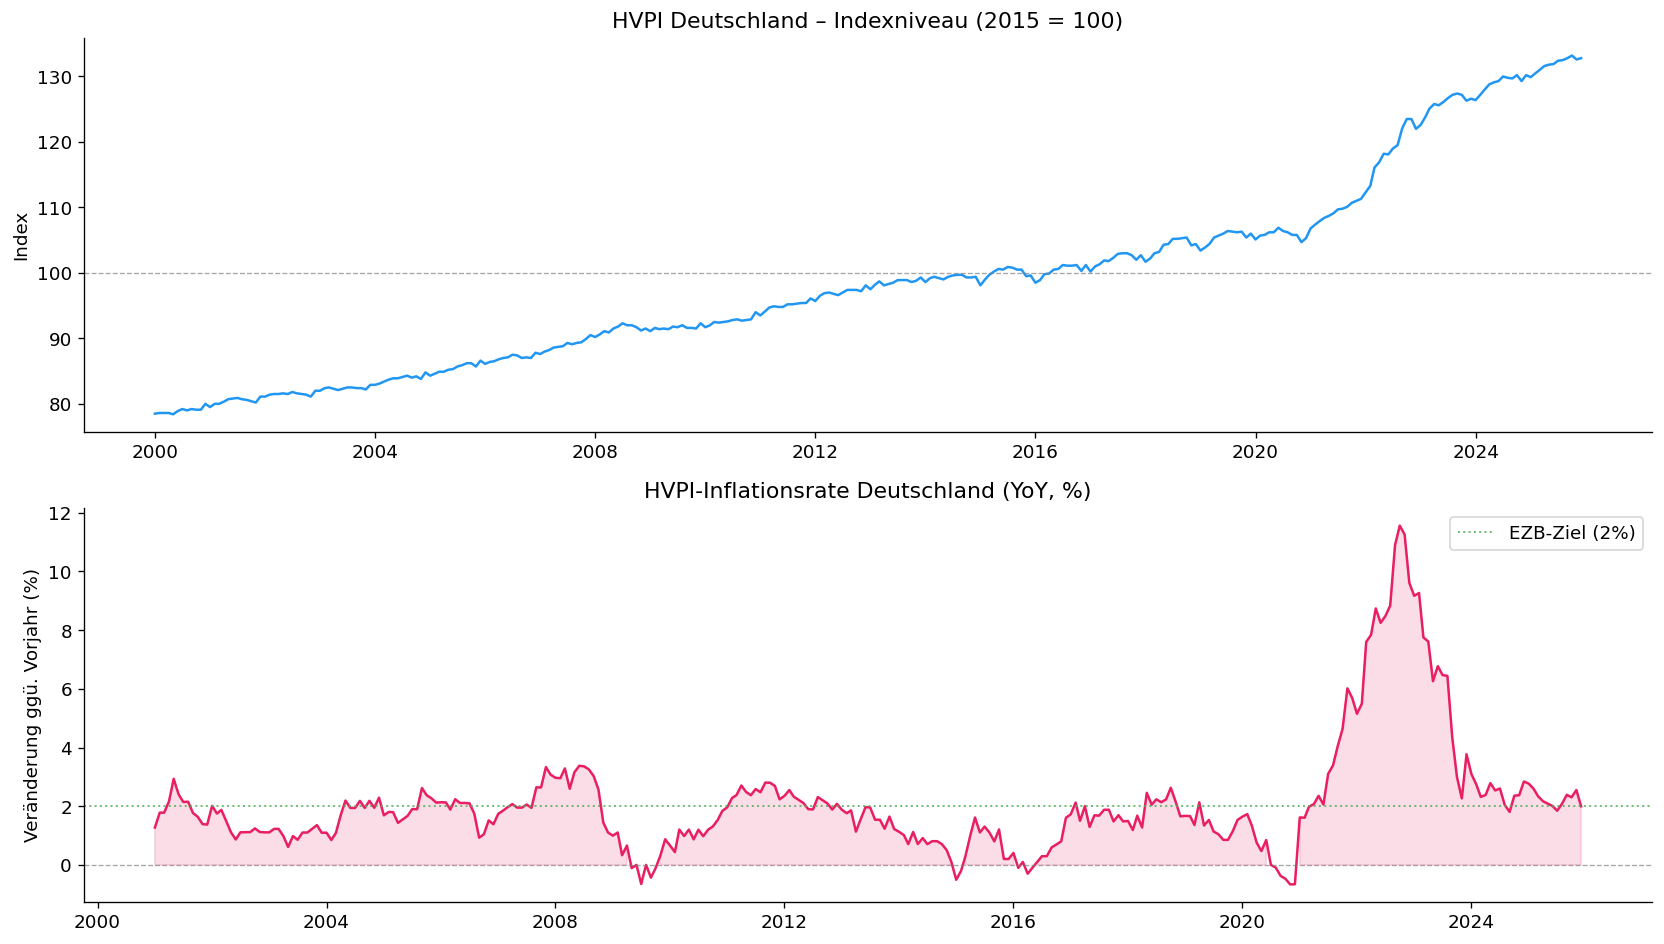

Abbildung gespeichert: fig_01_hvpi_zeitreihe.png


In [6]:
fig_01_hvpi(df_raw, df_yoy)

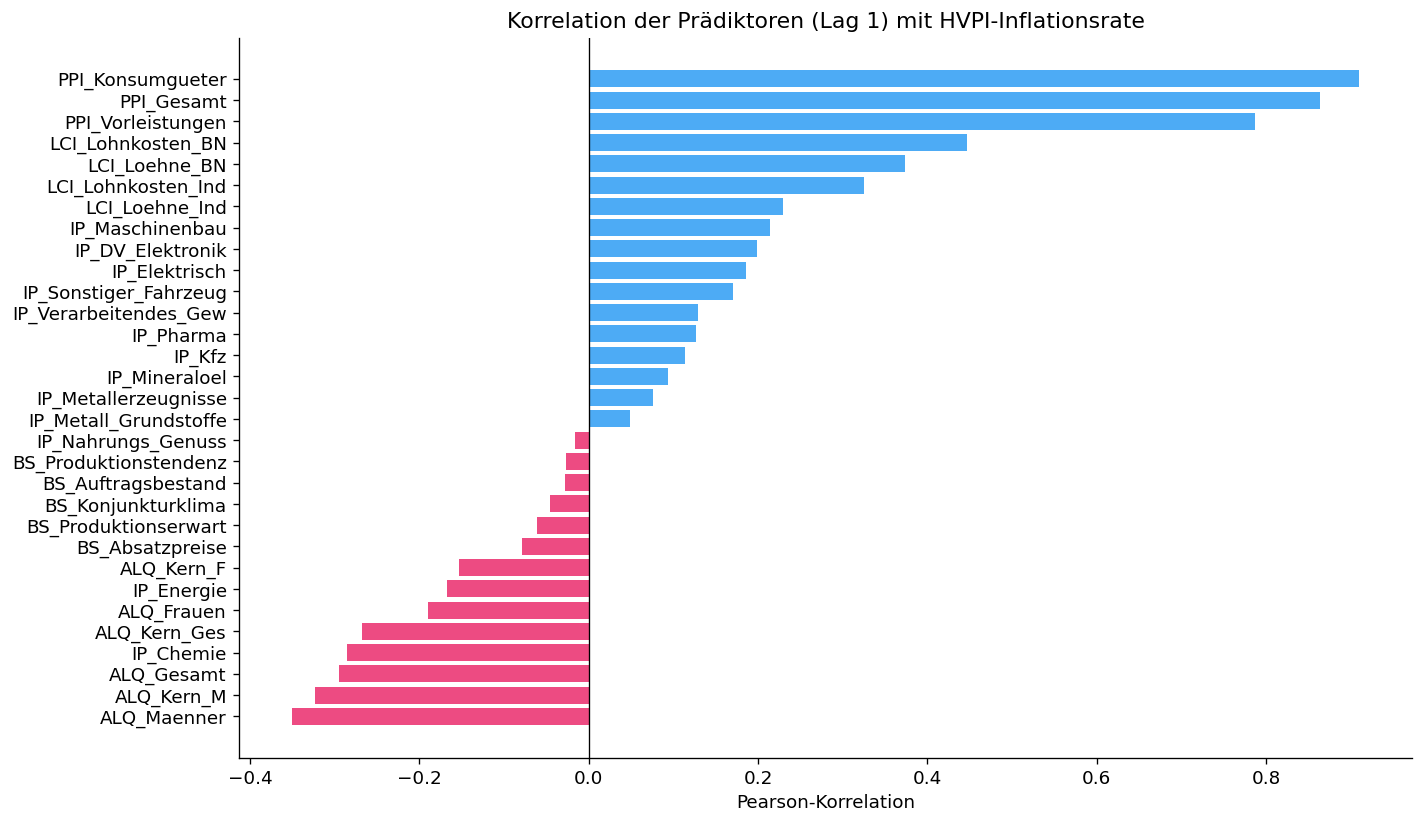

Abbildung gespeichert: fig_02_korrelation.png


In [7]:
fig_02_correlation(X, y)

### 2b. Multikollinearität der Prädiktoren

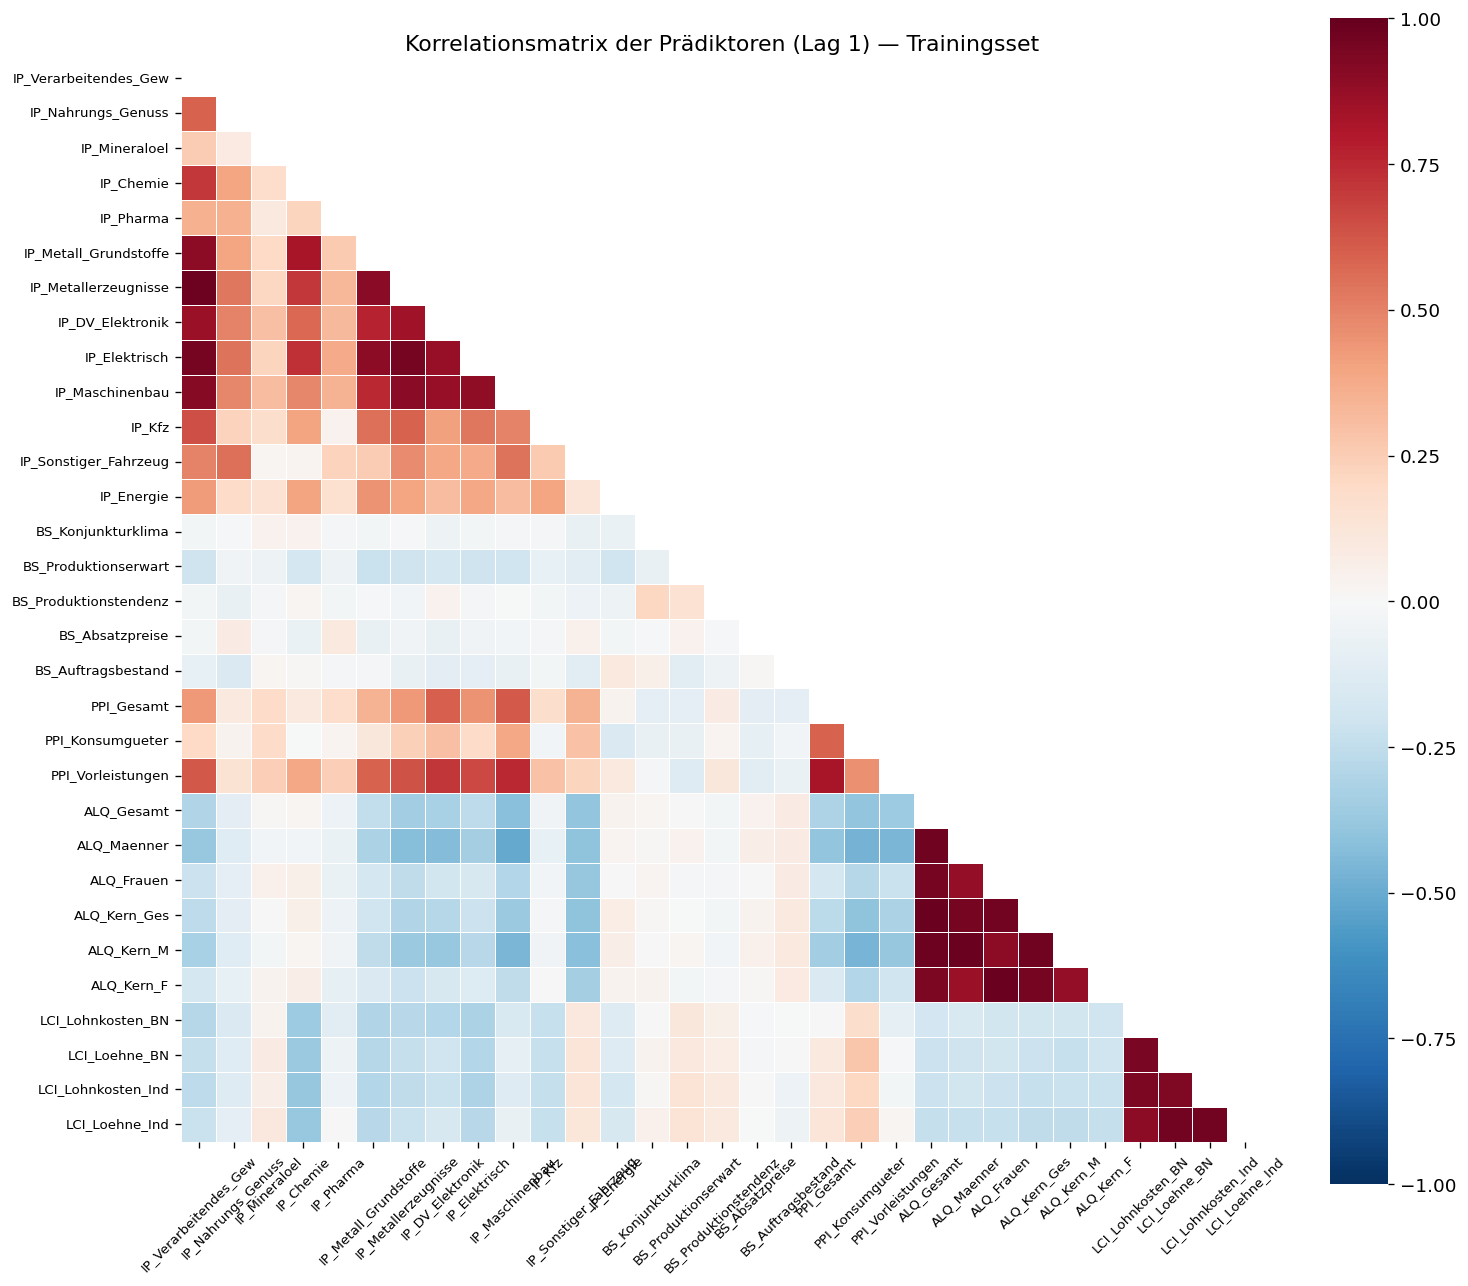

Abbildung gespeichert: fig_02b_korr_heatmap.png

Konditionszahl von X'X (standardisiert): 2.01e+05
→ Werte >> 1 bestätigen starke Multikollinearität und erklären OLS-Instabilität.


In [8]:
fig_02b_heatmap(X, train_end)

### 2c. Stationaritätstests (ADF/KPSS)

YoY-Jahresveränderungsraten gelten als Standardtransformation zur Stationarisierung integrierter Makroreihen. Die folgenden ADF- und KPSS-Tests belegen dies testgestützt für HVPI und repräsentative Prädiktoren aus fünf Sektorgruppen.

**ADF** (H₀: Einheitswurzel): Verwerfung bei *p* < 0,05 → stationär.  
**KPSS** (H₀: Stationarität): Nicht-Verwerfung bei *p* ≥ 0,05 → stationär.

**Befund:** Industrieproduktion, PPI, Business Surveys und Arbeitslosigkeit sind nach YoY-Transformation klar stationär (ADF verwirft, KPSS verwirft nicht). HVPI-YoY zeigt *hohe Persistenz* (ADF p ≈ 0,015, KPSS p ≈ 0,044 — beide nahe am 5 %-Grenzwert), konsistent mit der bekannten Trägheit von Inflationsreihen (Stock & Watson 2007). Dies ist ein empirischer Befund, kein Verfahrensfehler: die YoY-Transformation reduziert die Persistenz des HVPI-Niveaus (ADF p > 0,99) deutlich und entspricht dem ökonometrischen Standard.

In [ ]:
stat_ctx = compute_stationarity_tests(df_raw, df_yoy)
export_stationarity_table(stat_ctx["df_stationarity"])
ctx.update(stat_ctx)

## 3. Modellschätzung: OLS, Ridge, LASSO

In [9]:
splits  = prepare_splits(X, y, train_end)

y_train    = splits["y_train"];  y_test    = splits["y_test"]
X_train    = splits["X_train"];  X_train_s = splits["X_train_s"]

print(f"Trainingsdaten: {len(y_train)} Monate "
      f"({y_train.index[0].strftime('%Y-%m')} \u2013 {y_train.index[-1].strftime('%Y-%m')})")
print(f"Testdaten:      {len(y_test)} Monate "
      f"({y_test.index[0].strftime('%Y-%m')} \u2013 {y_test.index[-1].strftime('%Y-%m')})")
print(f"\nDimensionen: {X_train.shape[0]} Train \u00d7 {X_train.shape[1]} Features")
print(f"n < p: {'JA (hochdimensional)' if X_train.shape[0] < X_train.shape[1] else 'NEIN'}")

Trainingsdaten: 225 Monate (2002-01 – 2021-05)
Testdaten:      36 Monate (2021-06 – 2024-10)

Dimensionen: 225 Train × 155 Features
n < p: NEIN


In [10]:
print("Standardisierung abgeschlossen.")
print(f"Trainings-Mittelwerte ~0: {abs(X_train_s.mean(axis=0)).max():.2e}")
print(f"Trainings-Std ~1:         {abs(X_train_s.std(axis=0) - 1).max():.2e}")

Standardisierung abgeschlossen.
Trainings-Mittelwerte ~0: 3.16e-16
Trainings-Std ~1:         2.22e-16


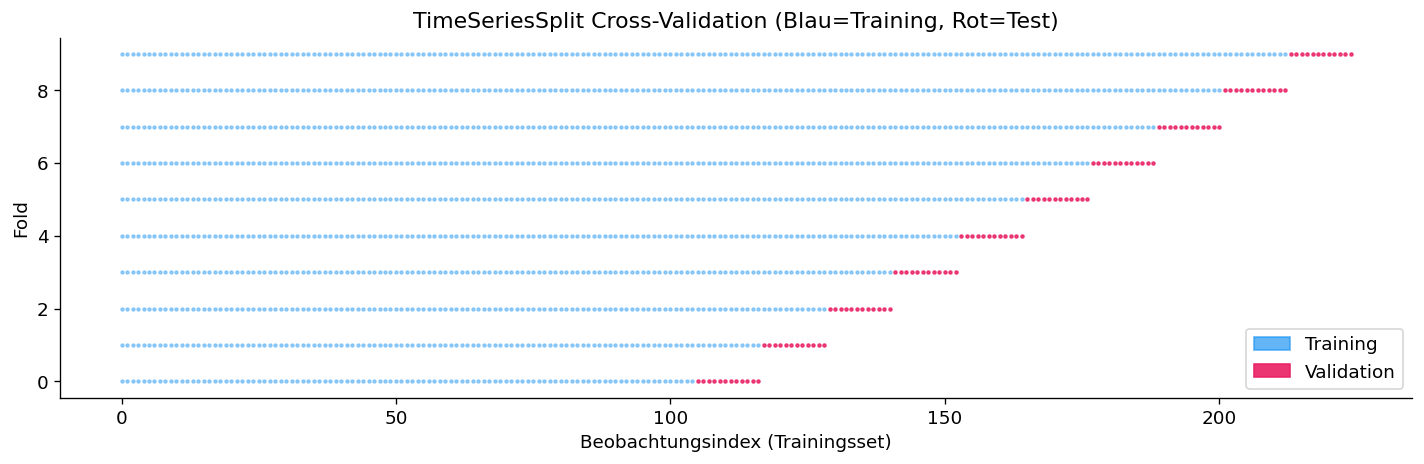

In [11]:
fig_03_tscv(splits["X_train_s"], config.TSCV)

## 3.5 Benchmarks: Random Walk & Lag-Modell (ADL)

Das **Lag-Modell (ADL)** verwendet ausschließlich HVPI-Eigen-Lags {1, 2, 3, 6, 12} als Prädiktoren — es ist damit ein *restringiertes AR-Modell* ohne exogene Regressoren. Die Bezeichnung „ADL" ist hier als Oberbegriff gewählt; da keine exogenen Größen eingehen, entspricht es inhaltlich einem autoregressiven Modell mit ausgewählten Lags.

In [12]:
models_ctx = fit_all_models(X, y, splits, tscv=config.TSCV)

# Convenience-Aliase
ols           = models_ctx["ols"]
ridge_cv      = models_ctx["ridge_cv"]
lasso_cv      = models_ctx["lasso_cv"]
enet_cv       = models_ctx["enet_cv"]
alasso        = models_ctx["alasso"]
ar_model      = models_ctx["ar_model"]
lasso_plus_cv = models_ctx["lasso_plus_cv"]
lambda_ridge  = models_ctx["lambda_ridge"]
lambda_lasso  = models_ctx["lambda_lasso"]
lambda_enet   = models_ctx["lambda_enet"]
l1_ratio_enet = models_ctx["l1_ratio_enet"]
results       = models_ctx["results"]
selected      = models_ctx["selected"]
top_idx       = models_ctx["top_idx"]

Random Walk – Test MSE: 0.8833  |  RMSE: 0.9398  |  R²: 0.8933
Lag-Modell (ADL)      – Test MSE: 1.1114  |  RMSE: 1.0542  |  R²: 0.8657
LASSO+HVPI – λ=0.06368, MSE=2.1741, RMSE=1.4745, R²=0.7374, Koeff.≠0: 7/160
OLS – Train MSE: 0.0242  |  Test MSE: 11.5850
OLS – Test R²:   -0.3994
OLS – Nicht-Null-Koeffizienten: 155/155
Ridge – Optimales λ (Cross-Validation): 54.7890
Ridge – Train MSE: 0.1044  |  Test MSE: 3.8303
Ridge – Test R²:   0.5373
LASSO – Optimales λ (Cross-Validation): 0.029673
LASSO – Train MSE: 0.1383  |  Test MSE: 3.3534
LASSO – Test R²:   0.5949
LASSO – Selektierte Variablen: 29/155 (18.7%)
Elastic Net – Optimales α: 0.039171, l1_ratio: 0.70
Elastic Net – Train MSE: 0.1362  |  Test MSE: 3.4056
Elastic Net – Test R²:   0.5886
Adaptive LASSO – λ=0.00032, RMSE=1.3769, RMSE/RW=1.4651, R²=0.7710, Koeff.≠0: 50/155

Ergebnistabelle gespeichert: results_table.csv


## 4. Ergebnisvergleich

In [13]:
print("=" * 75)
print("Ergebnisübersicht: Benchmarks vs. Regularisierungsmodelle")
print("=" * 75)
print(results.to_string())
print("=" * 75)

# Kombinierten Kontext aufbauen (wird von Reporting-Funktionen genutzt)
inf_ctx = compute_single_split_inference(models_ctx, splits)

ctx = {
    "df_raw": df_raw, "df_yoy": df_yoy,
    "X": X, "y": y, "train_end": train_end,
    **splits, **models_ctx, **inf_ctx,
}

Ergebnisübersicht: Benchmarks vs. Regularisierungsmodelle
                        λ Train MSE  Test MSE  Test RMSE  RMSE/RW  Test R² Nicht-Null-Koeff.
Modell                                                                                      
Random Walk             -         -    0.8833     0.9398   1.0000   0.8933                 -
Lag-Modell (ADL)        -         -    1.1114     1.0542   1.1217   0.8657                 5
OLS                     -    0.0242   11.5850     3.4037   3.6216  -0.3994               155
Ridge              54.789    0.1044    3.8303     1.9571   2.0824   0.5373               155
LASSO             0.02967    0.1383    3.3534     1.8312   1.9485   0.5949                29
Elastic Net       0.03917    0.1362    3.4056     1.8454   1.9636   0.5886                34
LASSO+HVPI        0.06368         -    2.1741     1.4745   1.5689   0.7374           7 / 160
Adaptive LASSO    0.00032    0.0866    1.8959     1.3769   1.4651   0.7710                50


### 4.1 Inferenz auf dem Einzelsplit (Block-Bootstrap + DM-Test)

**Forschungsfrage:** Ist die Rangfolge der Haupttabelle auf T=36 Testpunkten
statistisch belastbar?

Zwei komplementäre Methoden:
- **Block-Bootstrap 95%-KI** (zirkulär, $l=6\approx\sqrt{T}$, $B=2000$): quantifiziert die
  Stichprobenvariabilität des RMSE bei seriell korrelierten Fehlern.
- **Diebold-Mariano-Test** (HLN-korrigiert, $h=1$): testet, ob der quadratische
  Prognosefehler eines Modells signifikant kleiner ist als der des Random Walk.

**Erwartetes Ergebnis:** Bei $T=36$ ist die Testpower gering — Unterschiede in der
Größenordnung von RMSE/RW $\approx 1{,}4$ vs. $1{,}0$ sind i.d.R. nicht signifikant.
Die Block-Bootstrap-KIs geben an, in welcher Bandbreite der wahre RMSE mit 95%
Wahrscheinlichkeit liegt.

In [ ]:
export_inference_table(inf_ctx["df_inference"], splits["y_test"])

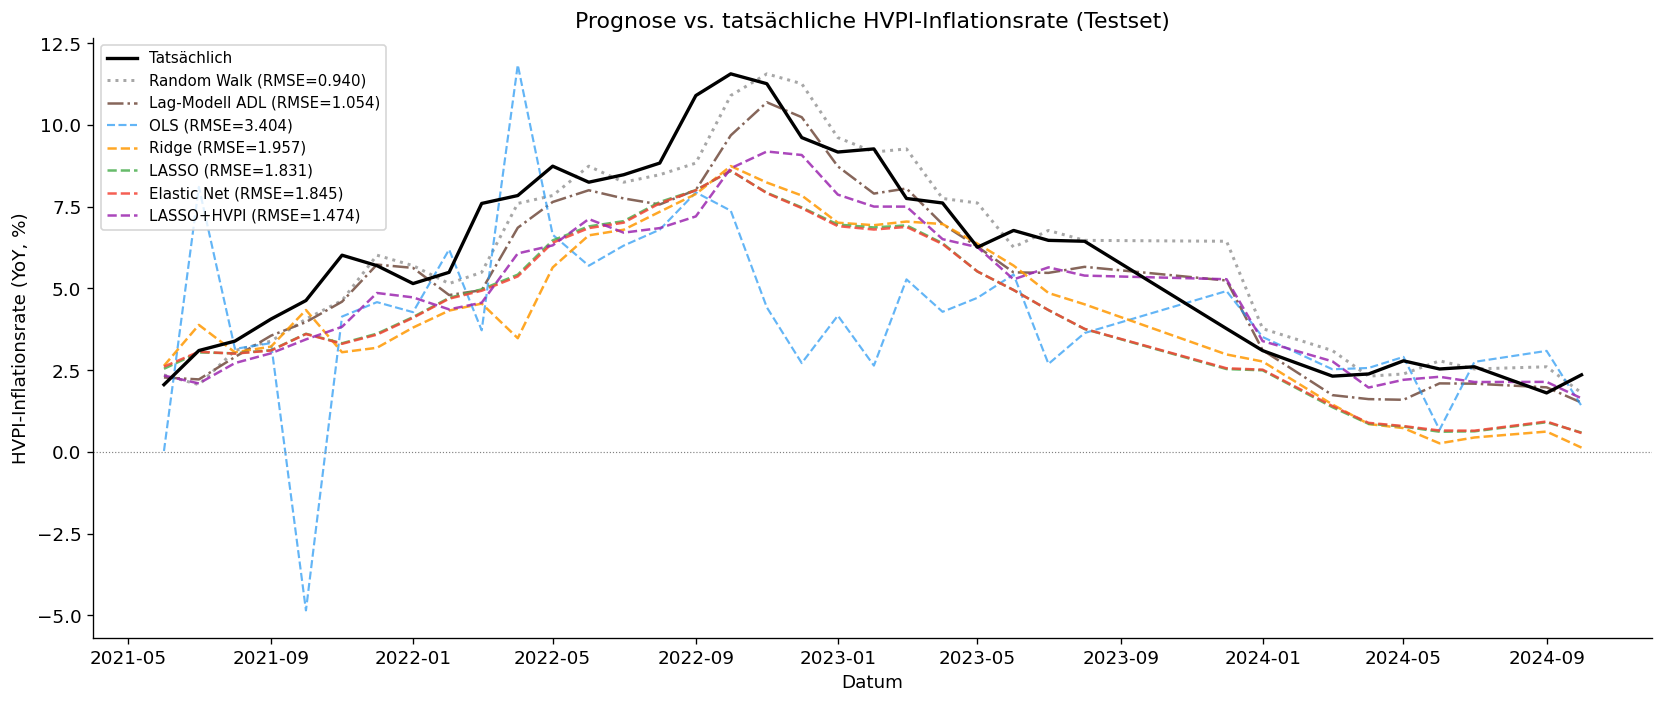

Abbildung gespeichert: fig_04_prognose.png


In [14]:
fig_04_forecast(ctx)

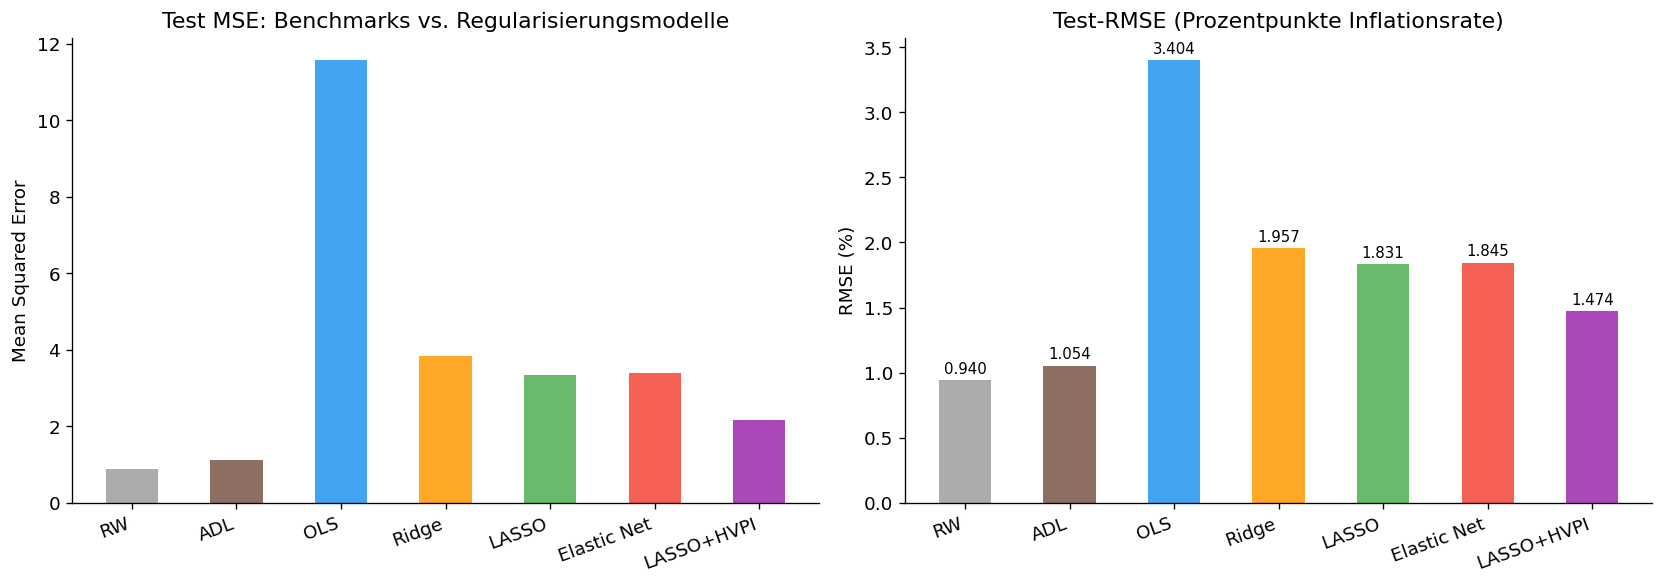

Abbildung gespeichert: fig_05_mse_vergleich.png


In [15]:
fig_05_mse_comparison(ctx)

## 4.5 Rolling-Origin Out-of-Sample

In [16]:
oos_ctx = compute_oos_predictions(models_ctx, splits, X, y, train_end)
ctx.update(oos_ctx)

Rolling-Origin-Prognosen berechnet (alle Modelle inkl. Elastic Net).
Rolling-Origin RMSE (Expanding Window, h=1, λ fest aus initialem CV):
-----------------------------------------------------------------
  RW            : RMSE = 0.9398   RMSE/RW = 1.000 (Ref)
  AR            : RMSE = 0.9499   RMSE/RW = 1.011
  OLS           : RMSE = 2.3430   RMSE/RW = 2.493
  Ridge         : RMSE = 1.1592   RMSE/RW = 1.233
  LASSO         : RMSE = 1.0865   RMSE/RW = 1.156
  Elastic Net   : RMSE = 1.0903   RMSE/RW = 1.160
  LASSO+HVPI    : RMSE = 0.9500   RMSE/RW = 1.011


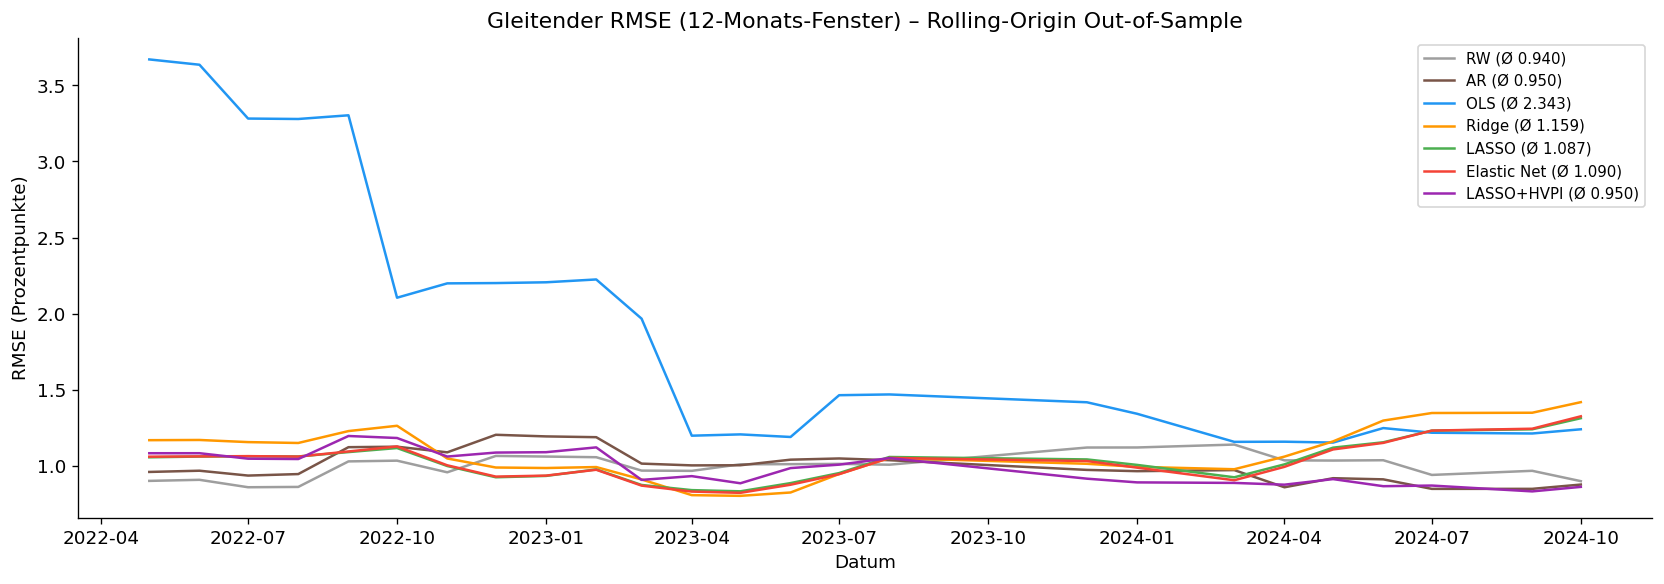

Abbildung gespeichert: fig_11_rolling_rmse.png


In [17]:
fig_11_rolling_rmse(oos_ctx["oos_df"], oos_ctx["y_oos_ref"], oos_ctx["oos_rmse"])

In [18]:
adap_ctx    = compute_adaptive_oos(X, y, splits, train_end, config.TSCV_INNER)
compare_ctx = compute_compare_oos(oos_ctx, adap_ctx, oos_ctx["y_oos_ref"])
ctx.update({**adap_ctx, **compare_ctx})

Starte adaptive Rolling-Origin (λ je Origin via CV) …
(Laufzeit ~10–20 min — Fortschritt wird nicht angezeigt)
Fertig.

Rolling-Origin RMSE: festes λ vs. adaptives λ je Origin
Modell                       RMSE   RMSE/RW
---------------------------------------------
  RW                       0.9398    1.0000
  AR                       0.9499    1.0107
  LASSO                    1.0865    1.1561
  LASSO (adapt.)           1.2421    1.3217 ◀ adapt.
  Ridge                    1.1592    1.2334
  Ridge (adapt.)           1.4230    1.5141 ◀ adapt.
  Elastic Net              1.0903    1.1601
  Elastic Net (adapt.)     1.2332    1.3122 ◀ adapt.
  LASSO+HVPI               0.9500    1.0109
  LASSO+HVPI (adapt.)      1.0027    1.0669 ◀ adapt.
  Adaptive LASSO (adapt.)  0.9937    1.0574 ◀ adapt.


### 4.5.1 Einzelfenster vs. Rolling-Origin: Methodische Einordnung

Die Ergebnisse in Abschnitt 4 (fester Einzelsplit) und 4.5 (Rolling-Origin) weichen für
einige Modelle erheblich voneinander ab — das ist kein Widerspruch, sondern informativ:

| Modell | Einzelfenster RMSE | Rolling-Origin RMSE | Differenz |
|--------|-------------------:|--------------------:|----------:|
| Random Walk | 0.94 | 0.94 | ≈ 0 |
| AR (ADL) | 1.05 | 0.95 | −0.10 |
| LASSO+HVPI | 1.47 | 0.95 | −0.52 |
| LASSO | 1.83 | 1.09 | −0.74 |
| Elastic Net | 1.85 | 1.09 | −0.76 |
| Ridge | 1.96 | 1.16 | −0.80 |
| OLS | 3.40 | 2.34 | −1.06 |

**Mechanistische Erklärung der Diskrepanz:**

*Einzelfenster (fester Split 2021-06 bis 2024-10):* λ und alle Modellgewichte werden
**einmalig** auf dem Vor-PandemieDatensatz (bis 2021-05) geschätzt und dann starr auf
das Testfenster angewandt. Das Testfenster umfasst ausgerechnet den außergewöhnlichen
Energiepreis-/Inflationsschock 2021–2022 — ein Regime, das im Training nicht vorkam.
Modelle mit vielen Parametern (Ridge, LASSO mit Makro-Features) scheitern hier besonders,
weil die einmalig geschätzten Koeffizienten diesen Schock systematisch verpassen.

*Rolling-Origin (Expanding Window):* Das Modell wird **monatlich neu geschätzt** —
sobald die Schock-Monate im Trainingsfenster auftauchen, passen sich die Gewichte an.
AR und LASSO+HVPI profitieren am stärksten, weil die HVPI-Eigen-Lags den Inflations-
impuls schnell adaptieren.

**Konsequenz für die Ergebnisdarstellung:** Das Rolling-Origin-Design ist methodisch
robuster und wird als **Hauptergebnis** geführt. Der feste Einzelsplit dient als
Illustration der Regimeabhängigkeit: Er zeigt, wie anfällig reine Makro-Modelle ohne
Inflationspersistenz-Information für unerwartete Regimewechsel sind.

> *Beide Designs bestätigen den Kernbefund:* kein Makro-Modell ohne HVPI-Eigen-Lags
> schlägt den Random Walk; erst LASSO+HVPI und AR erreichen ihn (rolling) knapp.
> Die Signifikanz dieses Abstands prüft der Diebold-Mariano-Test im nächsten Abschnitt.


In [19]:
dm_ctx = compute_dm_tests(oos_ctx, adap_ctx=adap_ctx)
ctx.update(dm_ctx)

Diebold-Mariano-Test (Referenz: Random Walk, h=1, HLN-Korrektur, T=36)
Modell            DM-Stat    p-Wert  Signifikanz
--------------------------------------------------
  AR               -0.128    0.8990         n.s.
  LASSO+HVPI       -0.093    0.9267         n.s.
  LASSO            -0.955    0.3463         n.s.
  Elastic Net      -0.975    0.3361         n.s.
  Ridge            -1.454    0.1548         n.s.
  OLS              -1.870    0.0698            *
--------------------------------------------------
DM > 0: Modell schlägt Random Walk (niedr. Verlust)  | * p<0.10  ** p<0.05


### 4.6 Selektionsstabilität (LASSO)

In [20]:
sel_ctx = compute_selection_stability(X, y, train_end, models_ctx["lambda_lasso"])
ctx.update(sel_ctx)

Variablen selektiert in ≥1 Fenster:    57
Variablen selektiert in ≥50 % Fenster: 29

Top-15 nach Auswahlhäufigkeit:
IP_Kfz_L6                1.000000
PPI_Gesamt_L1            1.000000
IP_Energie_L12           1.000000
IP_Energie_L3            1.000000
IP_Pharma_L1             1.000000
IP_Pharma_L2             1.000000
LCI_Lohnkosten_Ind_L1    1.000000
PPI_Vorleistungen_L12    1.000000
ALQ_Frauen_L1            1.000000
PPI_Konsumgueter_L1      1.000000
PPI_Vorleistungen_L1     1.000000
IP_Energie_L1            1.000000
BS_Auftragsbestand_L6    1.000000
LCI_Lohnkosten_Ind_L3    1.000000
BS_Absatzpreise_L3       0.944444


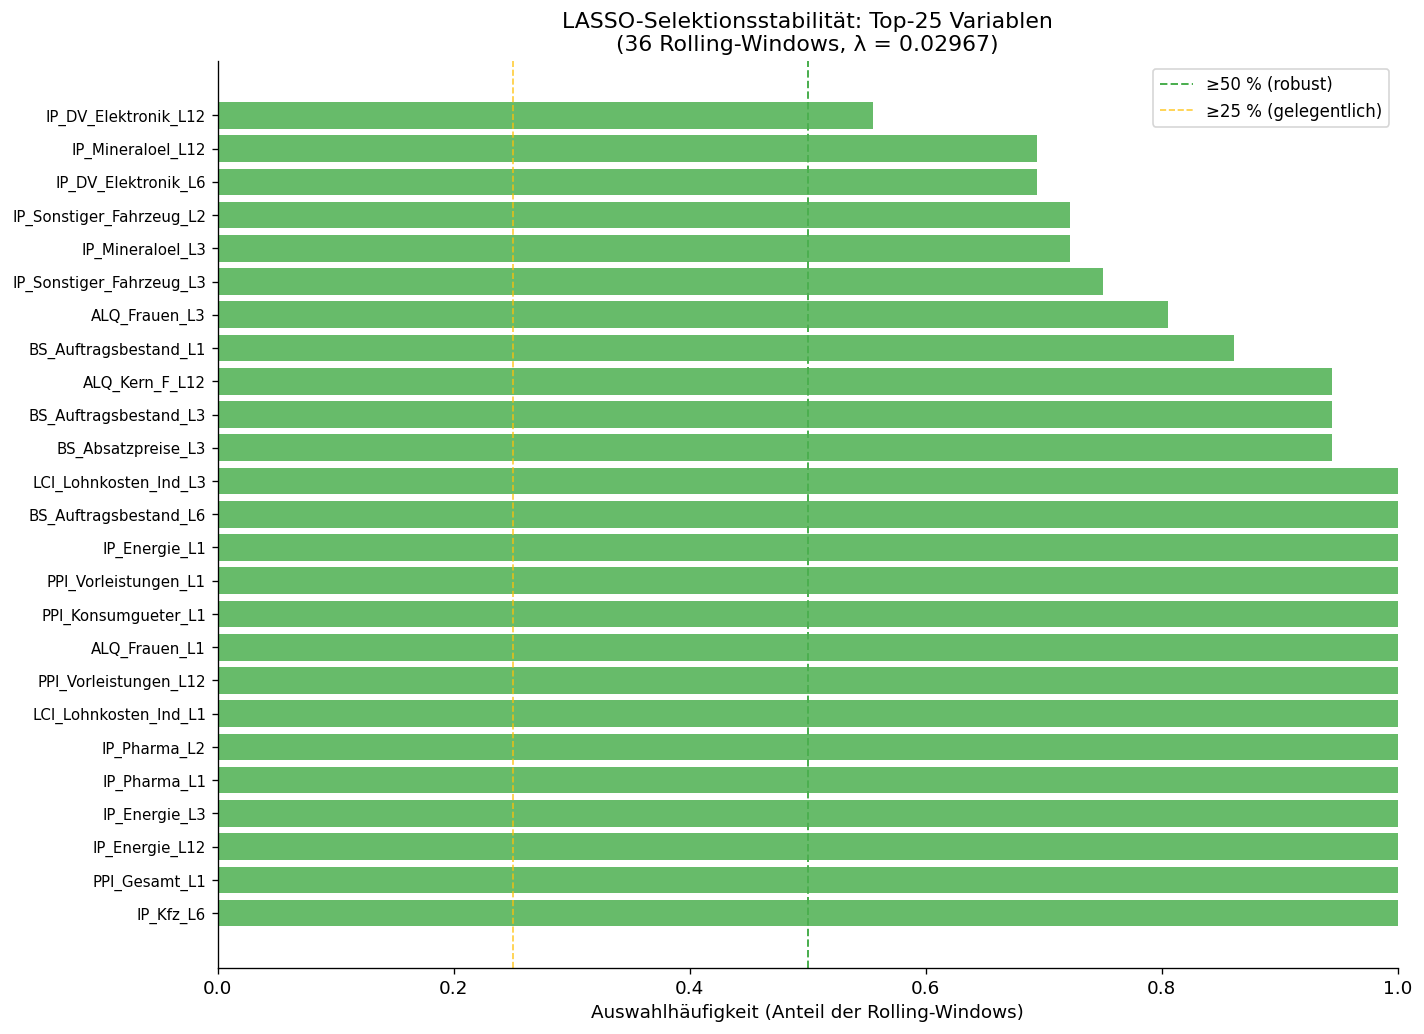

Abbildung gespeichert: fig_12_selektionsstabilitaet.png


In [21]:
fig_12_selection_stability(sel_ctx["sel_freq"], sel_ctx["n_windows"],
                           models_ctx["lambda_lasso"])

## 4.7 Mehrere Prognose-Horizonte

Vergleich der Modellgüte (RMSE) für h ∈ {1, 3, 6, 12} Monate voraus. Für jeden Horizont wird
`build_feature_matrix` mit `forecast_horizon=h` aufgerufen und λ via Cross-Validation neu bestimmt.
Die h-Schritt-Random-Walk-Prognose lautet ŷ_t = y_{t-h}.

In [22]:
hor_ctx = compute_horizon_analysis(df_yoy, tscv=config.TSCV)
ctx.update(hor_ctx)

  h       RW      OLS    Ridge    LASSO (sel)       EN (sel)
-----------------------------------------------------------------
h= 1: RW=0.940  OLS=3.404  Ridge=2.487  LASSO=1.831 ( 29)  EN=1.866 ( 29)
h= 3: RW=1.889  OLS=5.109  Ridge=3.455  LASSO=3.041 ( 15)  EN=3.235 ( 17)
h= 6: RW=2.845  OLS=5.633  Ridge=4.335  LASSO=3.876 ( 77)  EN=3.876 ( 77)
h=12: RW=4.593  OLS=5.678  Ridge=4.480  LASSO=4.031 (  6)  EN=4.074 (  7)
                  RW       OLS     Ridge     LASSO  LASSO Sel.  Elastic Net  EN Sel.
Horizont h                                                                          
1           0.939820  3.403676  2.486866  1.831237          29     1.866448       29
3           1.889273  5.109417  3.455063  3.041340          15     3.234790       17
6           2.844906  5.632653  4.334505  3.876463          77     3.876463       77
12          4.593448  5.678443  4.479894  4.031301           6     4.073789        7

Horizont-Tabelle gespeichert: results/horizons_table.csv


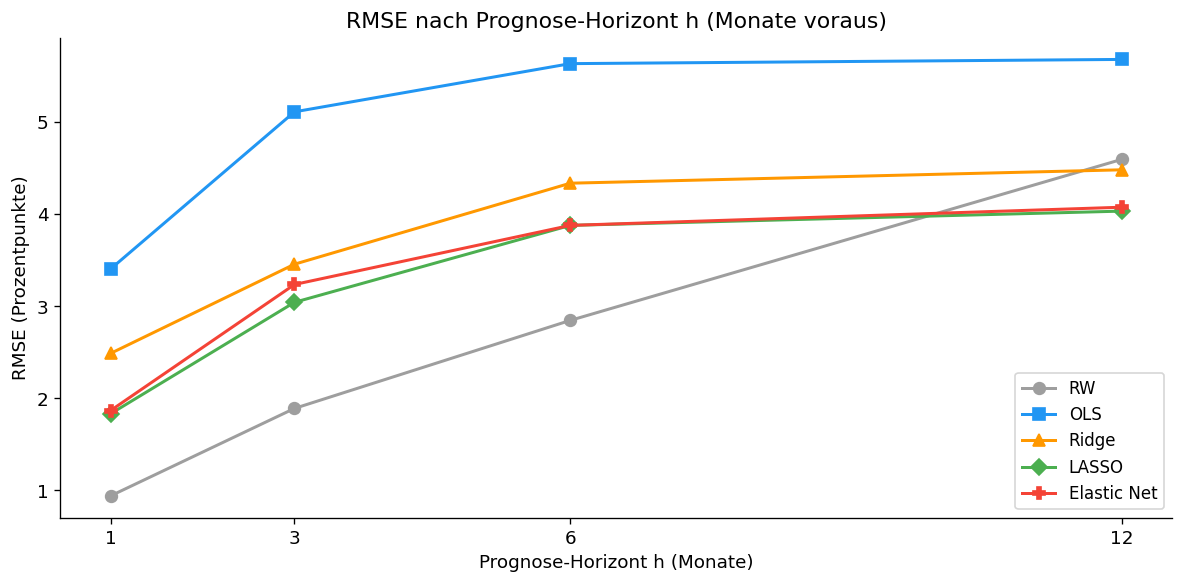

Abbildung gespeichert: fig_13_horizonte_rmse.png


In [23]:
fig_13_horizons(hor_ctx["df_horizons"])

**Befunde zur Horizont-Analyse:**  
Bei h = 6 sind LASSO und Elastic Net identisch (RMSE 3,876; 77 Selektion), weil `ElasticNetCV` für diesen Horizont `l1_ratio = 1,0` wählt und damit zur reinen L1-Strafe degeneriert.  
Die Selektionszahl steigt nicht-monoton (h=3: 15 → h=6: 77 → h=12: 6), weil das CV-optimale λ bei h=6 besonders klein ausfällt — der erhöhte Rauschanteil 6-Schritt-voraus lässt CV ein schwach regularisiertes Modell begünstigen, während bei h=12 das Signal so weit gedämpft ist, dass nur 6 Features das hohe λ überstehen.

## 5. Koeffizientenpfade & Variablenselektion

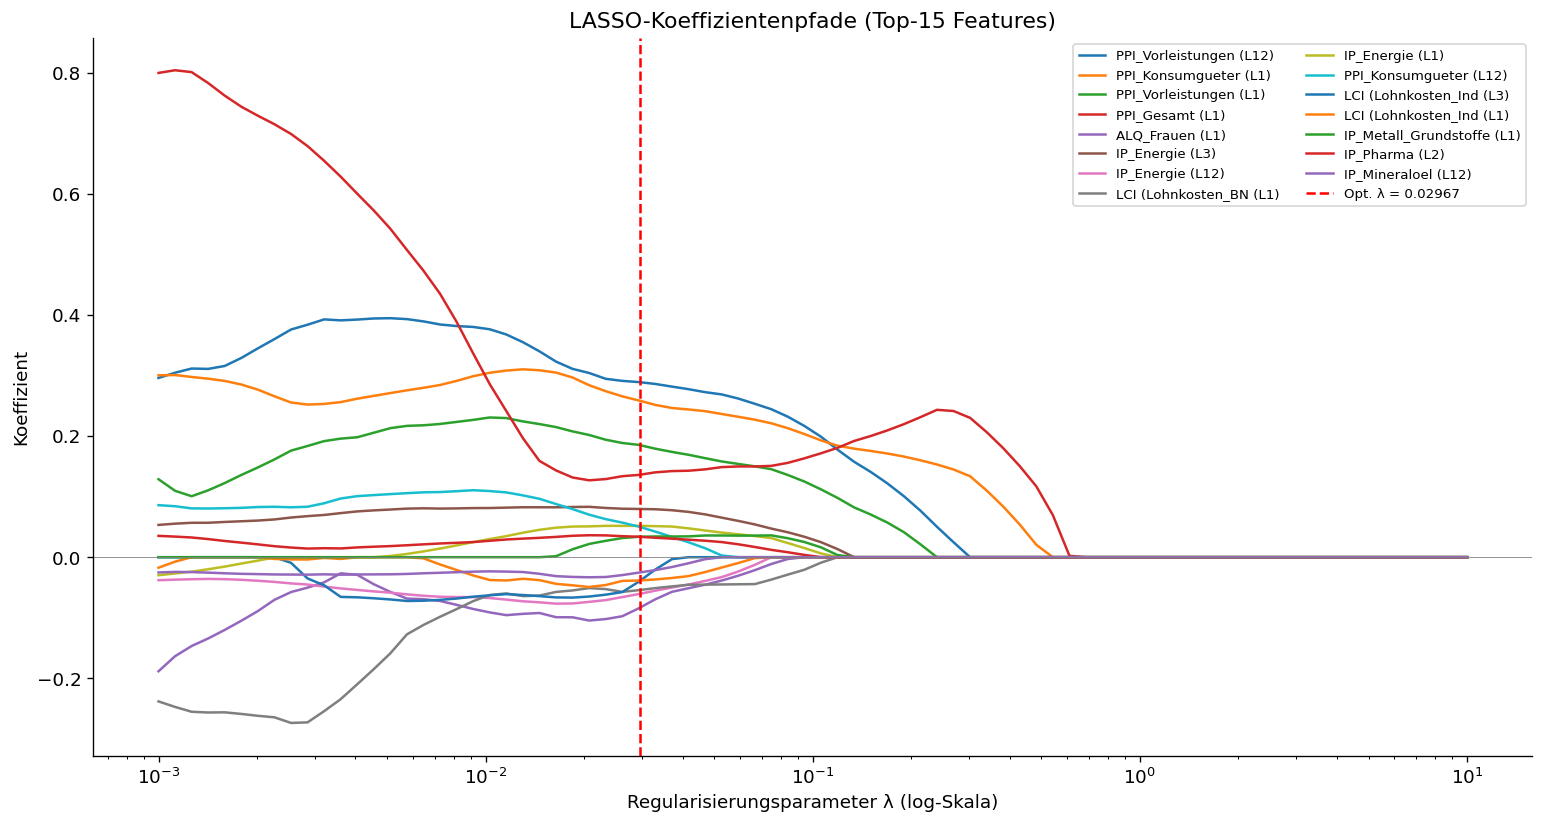

Abbildung gespeichert: fig_06_lasso_path.png


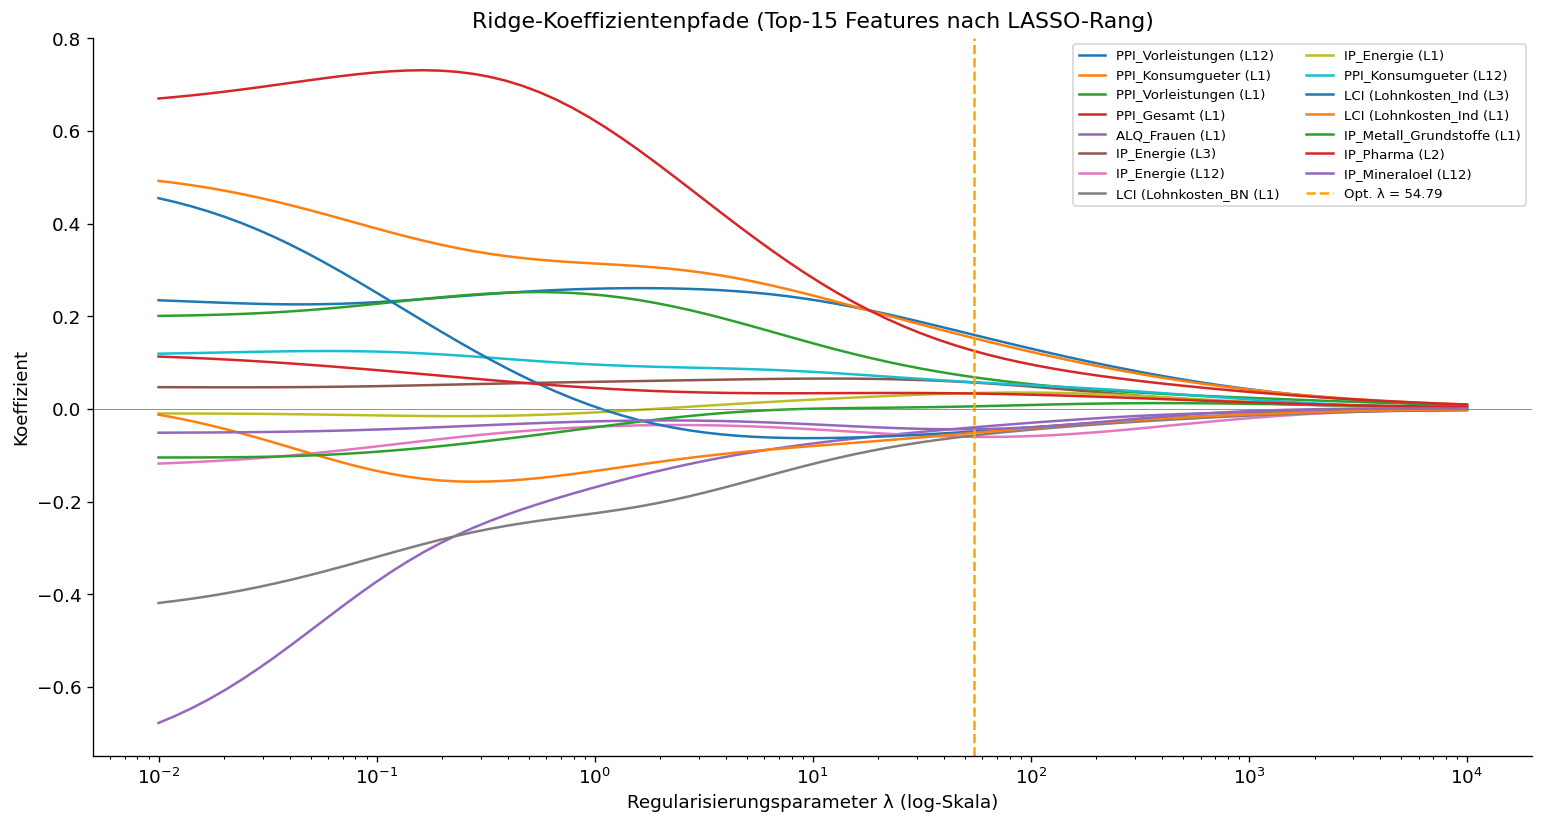

Abbildung gespeichert: fig_07_ridge_path.png


In [24]:
feat_names = X.columns.tolist()
fig_06_lasso_path(splits["X_train_s"], splits["y_train"], lasso_cv, feat_names)
fig_07_ridge_path(splits["X_train_s"], splits["y_train"], ridge_cv, top_idx, feat_names)

LASSO selektiert 29 von 155 Features:

PPI_Vorleistungen_L12       0.288852
PPI_Konsumgueter_L1         0.258320
PPI_Vorleistungen_L1        0.184968
PPI_Gesamt_L1               0.136150
ALQ_Frauen_L1              -0.083205
IP_Energie_L3               0.079567
IP_Energie_L12             -0.060398
LCI_Lohnkosten_BN_L1       -0.055691
IP_Energie_L1               0.051838
PPI_Konsumgueter_L12        0.049924
LCI_Lohnkosten_Ind_L3      -0.040043
LCI_Lohnkosten_Ind_L1      -0.036933
IP_Metall_Grundstoffe_L1    0.033847
IP_Pharma_L2                0.033680
IP_Mineraloel_L12          -0.025089
ALQ_Kern_F_L12              0.024031
IP_Maschinenbau_L1          0.023508
IP_Kfz_L6                   0.015859
BS_Auftragsbestand_L6       0.015254
LCI_Lohnkosten_BN_L3       -0.014293
IP_Pharma_L1                0.013050
BS_Auftragsbestand_L3       0.012644
BS_Absatzpreise_L3          0.011403
IP_Mineraloel_L3            0.009323
BS_Auftragsbestand_L1       0.005346
LCI_Loehne_BN_L6            0.003145

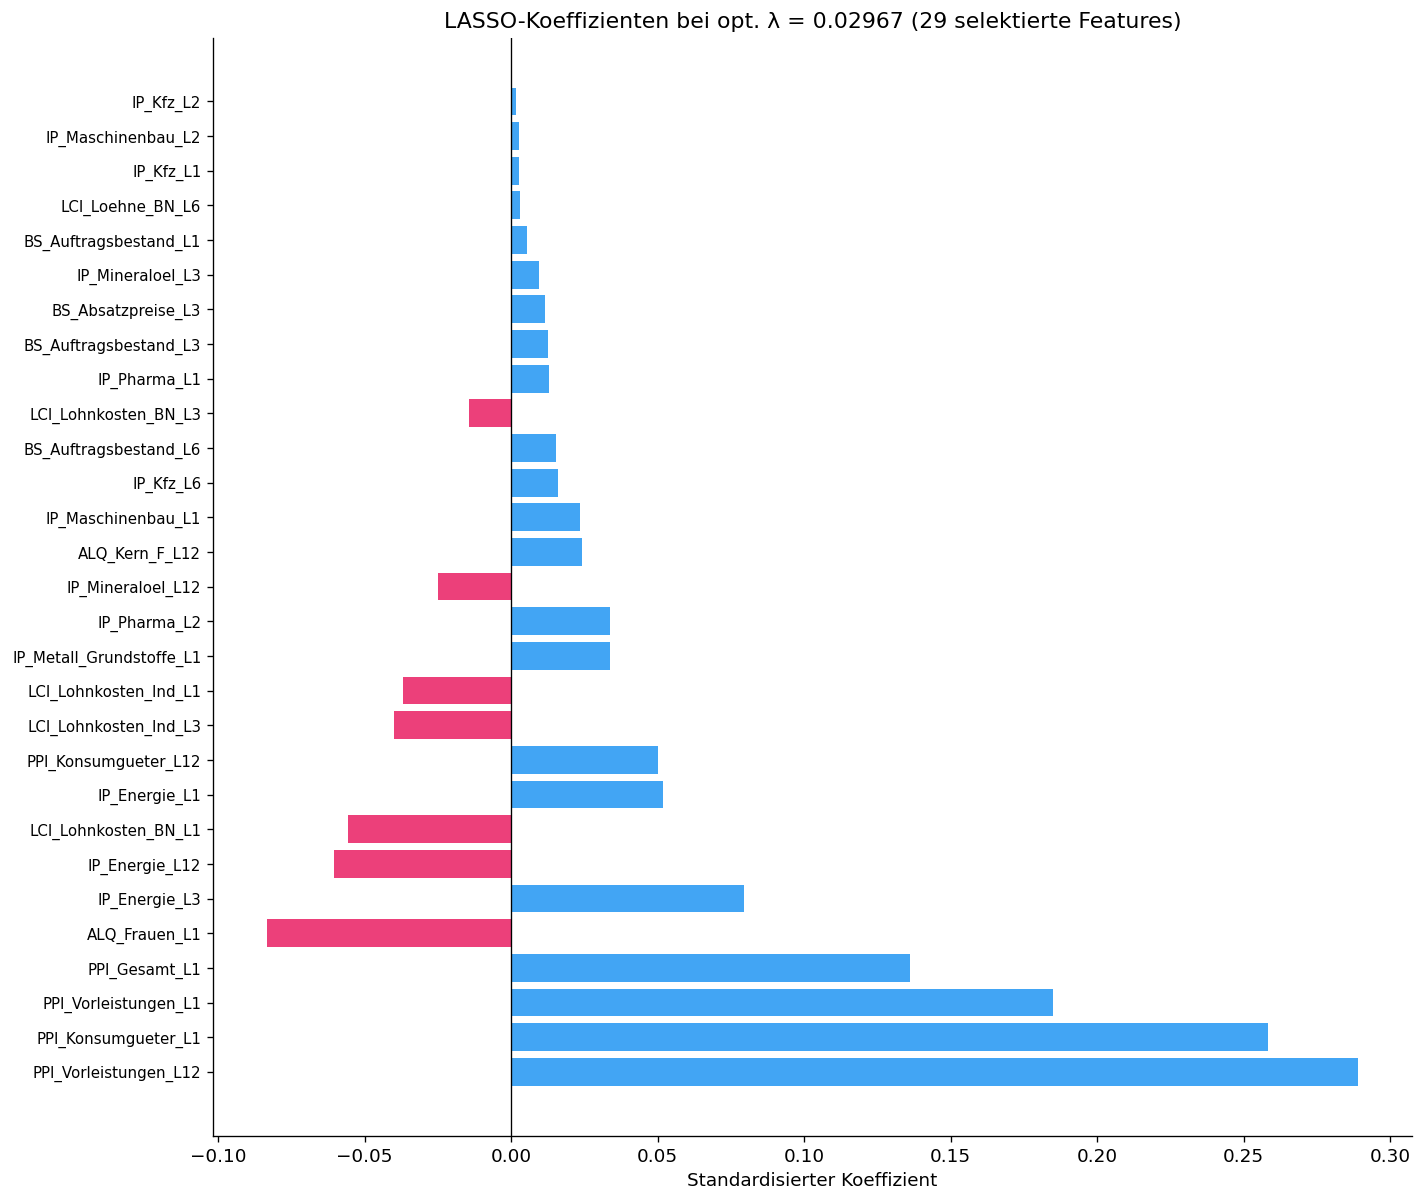


Abbildung gespeichert: fig_08_lasso_selektion.png


In [25]:
fig_08_lasso_selection(lasso_cv, X)

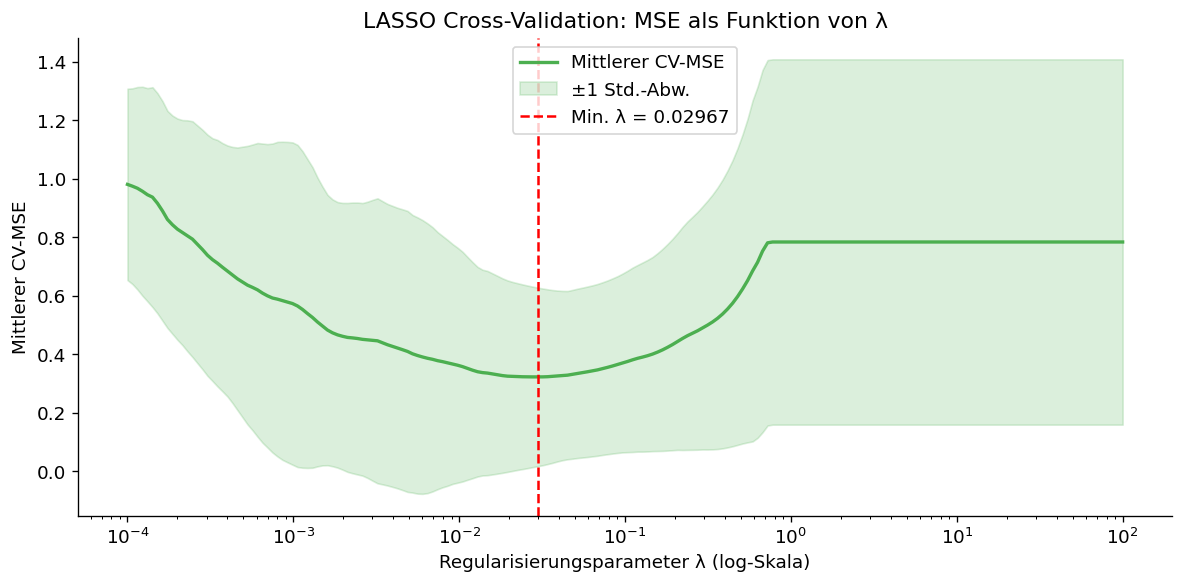

Abbildung gespeichert: fig_09_lasso_cv_path.png


In [26]:
fig_09_lasso_cv_path(lasso_cv)

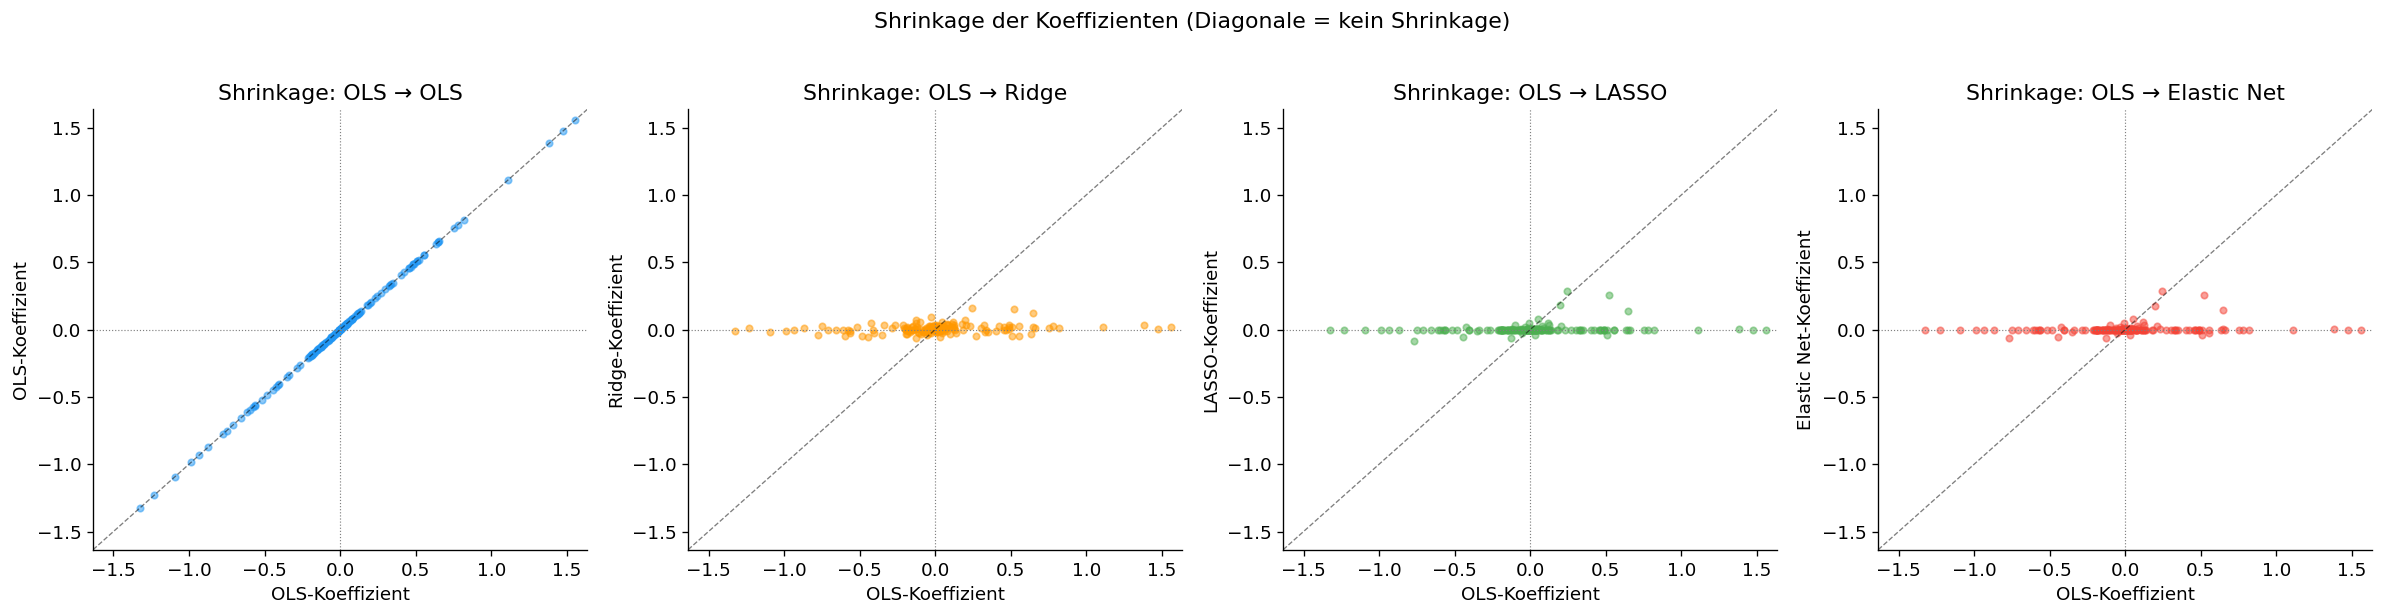

Abbildung gespeichert: fig_10_shrinkage.png


In [27]:
fig_10_shrinkage(ols, ridge_cv, lasso_cv, enet_cv)

## 6. Interpretation & Fazit

In [28]:
print_summary(ctx)

ZUSAMMENFASSUNG DER ERGEBNISSE
Datensatz:  261 Monate, 155 Features
Zeitraum:   2002-01 – 2024-10
Test-Split: 36 Monate (chronologisch)

Modell          Test-RMSE   RMSE/RW    Test-R²   Koeff.≠0
----------------------------------------------------------
Random Walk        0.9398 1.000 (Ref)     0.8933          -
ADL                1.0542     1.122     0.8657          5
OLS                3.4037     3.622    -0.3994        155
Ridge              1.9571     2.082     0.5373        155
LASSO              1.8312     1.948     0.5949         29
Elastic Net        1.8454     1.964     0.5886         34
LASSO+HVPI         1.4745     1.569     0.7374          7
Adapt. LASSO       1.3769     1.465     0.7710         50

Bestes Modell nach Test-RMSE: Random Walk

Selektierte Variablengruppen (LASSO):
  Industrieproduktion: 13 Feature(s) – ['IP_Energie_L3', 'IP_Energie_L12', 'IP_Energie_L1', 'IP_Metall_Grundstoffe_L1', 'IP_Pharma_L2', 'IP_Mineraloel_L12', 'IP_Maschinenbau_L1', 'IP_Kfz_L6', 'IP_Ph

### Interpretation der Ergebnisse

**1. Regularisierung behebt das OLS-Overfitting.** Bei p/n ≈ 0,69 (225 Beobachtungen, 155 Features) und ausgeprägter Multikollinearität (vgl. Konditionszahl in Abschnitt 2b) ist OLS unbrauchbar (Test-R² = −0,40). Ridge, LASSO und Elastic Net stabilisieren die Schätzung deutlich (Test-R² bis 0,77 (Adaptive LASSO) bzw. 0,74 (LASSO+HVPI), 0,59 ohne Eigen-Lags); LASSO erreicht dies mit nur 29 von 155 Variablen und liefert damit eine interpretierbare Selektion.

**2. Kein Makro-Modell schlägt den naiven Random Walk.** Der Random Walk (ŷ_t = y_{t−1}) hat mit RMSE ≈ 0,94 die beste Testgüte; LASSO liegt mit 1,83 rund 95 % darüber. Im robusteren Rolling-Origin-Design rücken die adaptiven Modelle (AR, LASSO+HVPI) bis an den RW heran (0,95 bzw. 0,95), schlagen ihn aber nicht klar — und über alle Horizonte h ∈ {1, 3, 6, 12} bleibt der RW die härteste Messlatte.

**3. Der Makro-Mehrwert über die Persistenz hinaus ist nahe null.** Erst das Modell mit den HVPI-Eigen-Lags (LASSO+HVPI) erreicht das RW-Niveau. Die reinen Makro-Modelle sind strukturell benachteiligt, weil ihnen der mit Abstand beste Einzelprädiktor — die letzte Inflationsrate — per Konstruktion fehlt.

**Einordnung.** Das Ergebnis ist konsistent mit der Literatur zur Inflationsprognose (Atkeson & Ohanian 2001; Stock & Watson 2007): strukturelle bzw. Phillips-Kurven-Modelle schlagen den naiven Benchmark in der Regel nicht. Die Kernaussage der Arbeit ist damit **nicht** „LASSO gewinnt", sondern: Regularisierung ist unverzichtbar, um in einem hochdimensionalen, kollinearen Prädiktorraum überhaupt stabil schätzen zu können — der ökonomische Prognosemehrwert gegenüber der reinen Persistenz bleibt jedoch gering.

**Limitationen:** Revidierte statt Echtzeit-Datenvintages; Testregime (2021–2024) maßgeblich vom Energiepreisschock geprägt — eingeschränkte externe Validität auf andere Inflationsregime. Prognoseunterschiede zum Random Walk sind bei T=36 statistisch nicht nachweisbar (Diebold-Mariano n.s.).

## 7. Aufbereitung & Export

Exportiert Tabellen als LaTeX-Fragmente (`results/*.tex`) und die Datenquellen-Tabelle als CSV + LaTeX für den Anhang. Abbildungen werden bei jedem `savefig`-Aufruf automatisch mit 300 DPI gespeichert (`savefig.dpi = 300` in den rcParams).

In [29]:
export_results_table(models_ctx["results"], splits["y_test"])
export_inference_table(inf_ctx["df_inference"], splits["y_test"])
export_horizons_table(hor_ctx["df_horizons"])
export_sources_table()

results/results_table.tex gespeichert.
\begin{table}
\caption{Prognosemodelle im Vergleich: mittlerer RMSE, relatives RMSE (RMSE/RW) und $R^2$ im Testset (Jun.~2021--Okt.~2024).}
\label{tab:ergebnisse}
\begin{tabular}{lllrrrrl}
\toprule
 & λ & Train MSE & Test MSE & Test RMSE & RMSE/RW & Test $R^2$ & Koeff.$\neq$0 \\
Modell &  &  &  &  &  &  &  \\
\midrule
Random Walk & - & - & 0.8833 & 0.9398 & 1.0000 & 0.8933 & - \\
Lag-Modell (ADL) & - & - & 1.1114 & 1.0542 & 1.1217 & 0.8657 & 5 \\
OLS & - & 0.0242 & 11.5850 & 3.4037 & 3.6216 & -0.3994 & 155 \\
Ridge & 54.789 & 0.1044 & 3.8303 & 1.9571 & 2.0824 & 0.5373 & 155 \\
LASSO & 0.02967 & 0.1383 & 3.3534 & 1.8312 & 1.9485 & 0.5949 & 29 \\
Elastic Net & 0.03917 & 0.1362 & 3.4056 & 1.8454 & 1.9636 & 0.5886 & 34 \\
LASSO+HVPI & 0.06368 & - & 2.1741 & 1.4745 & 1.5689 & 0.7374 & 7 / 160 \\
Adaptive LASSO & 0.00032 & 0.0866 & 1.8959 & 1.3769 & 1.4651 & 0.7710 & 50 \\
\bottomrule
\end{tabular}
\end{table}

Horizont-Tabelle als LaTeX gespeichert: re

## 8. README Auto-Synchronisation

Regeneriert den `Ergebnis-Überblick` in `README.md` aus den Live-Variablen
dieses Notebooks. Kein manuelles Pflegen von Zahlen nötig — einfach das
Notebook ausführen, dieser Block aktualisiert den README automatisch.


In [30]:
update_readmes(ctx)

/Users/anton/Desktop/SoSe26/Oekonometrie Seminar/RIDGE-LASSO-Inflation-Econometrics-SS26/README_DE.md ✓
/Users/anton/Desktop/SoSe26/Oekonometrie Seminar/RIDGE-LASSO-Inflation-Econometrics-SS26/README.md ✓

README auto-sync abgeschlossen.
  261 Beob. (2002-01–2024-10), 155 Features, Test 2021-06–2024-10
  RW 0.9398  |  LASSO 1.8312  |  OLS 3.4037
